# Week 5 - 2D Gaussian Score Field

**Diffusion contact:** 45-60 minutes  
**Companion note:** `notes/w05_2d_gaussian_score.md`  
**Goal:** implement and visualize the score field of a 2D Gaussian.

This solved notebook contains the completed implementation and checks for the 2D Gaussian score field.

## Outline

1. Set up a 2D Gaussian and plot density contours.
2. Implement the analytic score $s(x)=\nabla_x\log p(x)$.
3. Verify the score against finite differences.
4. Visualize score arrows over density contours.
5. Compare isotropic and correlated covariance fields.

Keep the scope tight: the important concept is that scores are vector fields pointing toward higher log-density.

---
## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(5)
plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=3, suppress=True)

---
## 1. Define a 2D Gaussian

We will reuse the covariance-matrix view from `w05_joint_gaussians.ipynb`.

In [2]:
mu = np.array([0.5, -0.25])
sigma_x = 1.2
sigma_y = 0.75
rho = 0.72

Sigma = np.array(
    [
        [sigma_x**2, rho * sigma_x * sigma_y],
        [rho * sigma_x * sigma_y, sigma_y**2],
    ]
)

assert Sigma.shape == (2, 2)
assert np.allclose(Sigma, Sigma.T)
assert np.all(np.linalg.eigvalsh(Sigma) > 0)

print("mean:", mu)
print("covariance:\n", Sigma)
print("precision:\n", np.linalg.inv(Sigma))

mean: [ 0.5  -0.25]
covariance:
 [[1.44  0.648]
 [0.648 0.562]]
precision:
 [[ 1.442 -1.661]
 [-1.661  3.691]]


The log-density is useful because the score is the gradient of log-density, not the gradient of density.

In [3]:
def gaussian_logpdf_2d(points, mean, cov):
    """Evaluate log N(points; mean, cov) for points with final dimension 2."""
    points = np.asarray(points)
    diff = points - mean
    inv_cov = np.linalg.inv(cov)
    quad = np.einsum("...i,ij,...j->...", diff, inv_cov, diff)
    log_norm = np.log(2 * np.pi) + 0.5 * np.log(np.linalg.det(cov))
    return -log_norm - 0.5 * quad

# Smoke test: the mean should have higher log-density than a distant point.
logp_mean = gaussian_logpdf_2d(mu, mu, Sigma)
logp_far = gaussian_logpdf_2d(mu + np.array([4.0, 4.0]), mu, Sigma)
assert logp_mean > logp_far

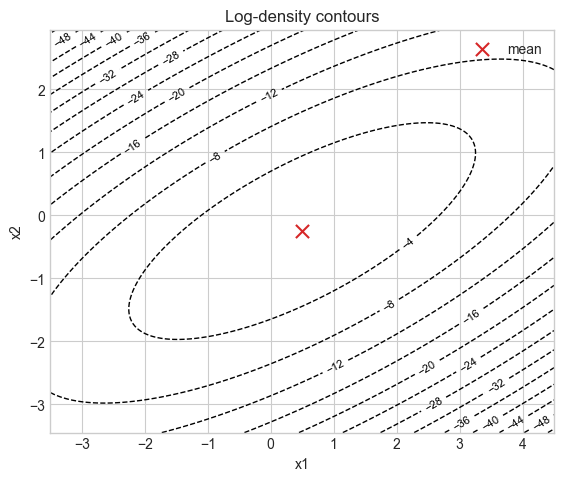

In [4]:
x_grid = np.linspace(mu[0] - 4.0, mu[0] + 4.0, 160)
y_grid = np.linspace(mu[1] - 3.2, mu[1] + 3.2, 160)
xx, yy = np.meshgrid(x_grid, y_grid)
grid = np.stack([xx, yy], axis=-1)
logp = gaussian_logpdf_2d(grid, mu, Sigma)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
contours = ax.contour(xx, yy, logp, levels=12, colors="black", linewidths=1.0)
ax.clabel(contours, inline=True, fontsize=8)
ax.scatter(mu[0], mu[1], color="tab:red", marker="x", s=90, label="mean")
ax.set(title="Log-density contours", xlabel="x1", ylabel="x2")
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.show()

---
## 2. Analytic Score

The note asks you to derive:

$$
\nabla_x\log \mathcal{N}(x;\mu,\Sigma) = -\Sigma^{-1}(x-\mu).
$$

Implement that formula below. The function should accept either one point shaped `(2,)` or many points shaped `(..., 2)`.

In [5]:
def score_2d(points, mean, cov):
    """Return the analytic score grad_x log N(points; mean, cov)."""
    points = np.asarray(points)

    # Precision matrix Sigma^{-1}.
    precision = np.linalg.inv(cov)

    # Displacement from the mean.
    diff = points - mean

    # Apply the precision matrix while preserving the leading point shape.
    return -np.einsum("ij,...j->...i", precision, diff)

# Self-check:
assert np.allclose(score_2d(mu, mu, Sigma), np.zeros(2))
assert score_2d(grid, mu, Sigma).shape == grid.shape

---
## 3. Finite-Difference Verification

A finite-difference gradient estimates each partial derivative numerically:

$$
\frac{\partial}{\partial x_i}\log p(x)
\approx
\frac{\log p(x+h e_i)-\log p(x-h e_i)}{2h}.
$$

This is slower than the analytic formula, but it is a good sanity check.

In [6]:
def finite_difference_score(point, mean, cov, h=1e-5):
    """Numerically approximate grad_x log N(x; mean, cov) at one 2D point."""
    point = np.asarray(point, dtype=float)
    grad = np.zeros_like(point)
    for idx in range(point.size):
        step = np.zeros_like(point)
        step[idx] = h
        plus = gaussian_logpdf_2d(point + step, mean, cov)
        minus = gaussian_logpdf_2d(point - step, mean, cov)
        grad[idx] = (plus - minus) / (2 * h)
    return grad

test_points = np.array(
    [
        mu,
        mu + np.array([1.0, 0.0]),
        mu + np.array([0.0, 1.0]),
        mu + np.array([1.2, -0.8]),
    ]
)

finite_scores = np.array([finite_difference_score(point, mu, Sigma) for point in test_points])
print("Finite-difference scores:\n", finite_scores)

# Compare analytic scores to finite-difference scores.
analytic_scores = score_2d(test_points, mu, Sigma)
max_error = np.max(np.abs(analytic_scores - finite_scores))
print("Analytic scores:\n", analytic_scores)
print("Max absolute error:", max_error)
assert max_error < 1e-6

Finite-difference scores:
 [[ 0.     0.   ]
 [-1.442  1.661]
 [ 1.661 -3.691]
 [-3.059  4.946]]
Analytic scores:
 [[-0.    -0.   ]
 [-1.442  1.661]
 [ 1.661 -3.691]
 [-3.059  4.946]]
Max absolute error: 4.6125769870286604e-11


---
## 4. Visualize the Score Field

Once `score_2d` works, the arrows should point uphill in log-density. Around the mean, the arrows should shrink toward zero.

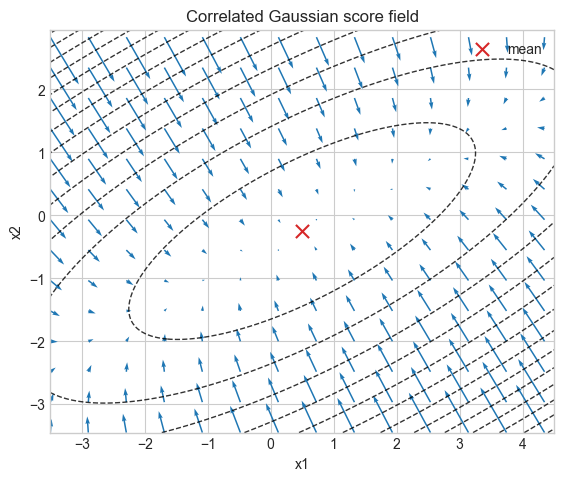

In [7]:
def plot_score_field(mean, cov, title, stride=12, arrow_scale=24):
    """Plot log-density contours and score arrows for a 2D Gaussian."""
    local_logp = gaussian_logpdf_2d(grid, mean, cov)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.contour(xx, yy, local_logp, levels=12, colors="black", linewidths=1.0, alpha=0.8)
    ax.scatter(mean[0], mean[1], color="tab:red", marker="x", s=90, label="mean")

    # Compute scores on a readable arrow grid.
    local_points = grid[::stride, ::stride]
    local_scores = score_2d(local_points, mean, cov)
    ax.quiver(
        local_points[..., 0],
        local_points[..., 1],
        local_scores[..., 0],
        local_scores[..., 1],
        color="tab:blue",
        angles="xy",
        scale_units="xy",
        scale=arrow_scale,
        width=0.003,
    )

    ax.set(title=title, xlabel="x1", ylabel="x2")
    ax.set_aspect("equal", adjustable="box")
    ax.legend()
    plt.show()

plot_score_field(mu, Sigma, "Correlated Gaussian score field")

---
## 5. Compare Covariance Shapes

Run the same visualization for two easier cases:

- isotropic covariance: same variance in every direction
- diagonal covariance: different variance per coordinate, no correlation

Then compare them to the correlated case.

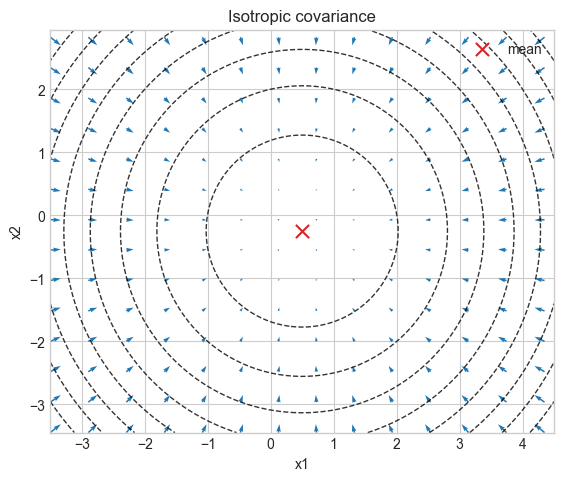

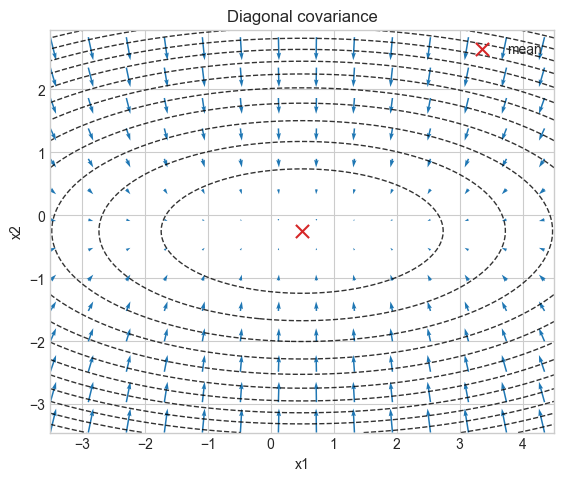

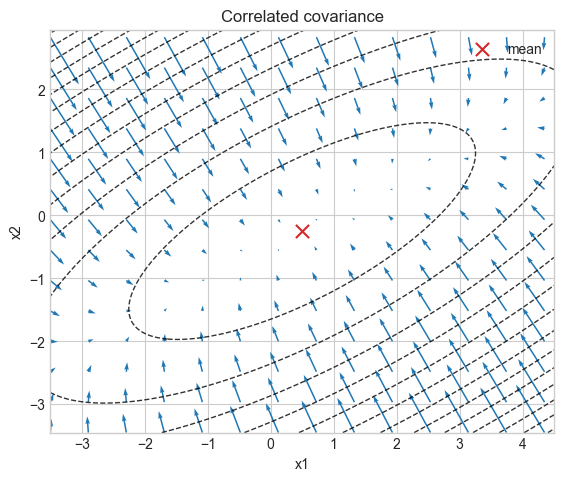

In [8]:
Sigma_isotropic = np.array([[1.0, 0.0], [0.0, 1.0]])
Sigma_diagonal = np.array([[1.8, 0.0], [0.0, 0.35]])

assert np.all(np.linalg.eigvalsh(Sigma_isotropic) > 0)
assert np.all(np.linalg.eigvalsh(Sigma_diagonal) > 0)

# Compare the score field geometry across covariance structures.
plot_score_field(mu, Sigma_isotropic, "Isotropic covariance")
plot_score_field(mu, Sigma_diagonal, "Diagonal covariance")
plot_score_field(mu, Sigma, "Correlated covariance")

## Reflection Prompt

Write 4-6 lines in your solved notebook:

- In the isotropic case, what do the arrows do?
- In the diagonal case, which direction has stronger pull?
- In the correlated case, how do the arrows relate to the tilted contours?
- Why is this score field a useful toy case for diffusion models?

1. In the isotropic case, the arrows point directly toward the mean because both axes have the same variance scale. Moving toward the mean is also the fastest way to reach higher log-density.
2. In the diagonal case, the stronger pull is in the vertical direction here. The horizontal variance is larger, so horizontal deviations are less surprising, while vertical deviations are penalized more strongly.
3. In the correlated case, the arrows are perpendicular to the tilted contour lines because the score is the gradient of the log-density. The arrows point in the fastest direction toward higher log-density, which may not be the straight Euclidean direction to the mean.
4. This is a useful toy case for diffusion models because the Gaussian score is known analytically and can be visualized. In realistic high-dimensional data, the score is unknown, so diffusion models train a neural network to approximate this kind of “direction back toward more typical data.”

## Takeaways

- A score in 2D is a vector attached to each point.
- The score points in the direction that most increases log-density.
- For a Gaussian, the score is linear in $x-\mu$.
- The precision matrix $\Sigma^{-1}$ controls the geometry of the pull.
- Diffusion models learn score fields when the true density is too complicated to write down.